### Importing necessary modules

In [3]:
import pandas as pd                                                                     # type: ignore
import matplotlib.pyplot as plt                                                         # type: ignore
import seaborn as sns                                                                   # type: ignore
import numpy as np                                                                      # type: ignore
import tensorflow as tf                                                                 # type: ignore
import matplotlib as mpl                                                                # type: ignore
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
mpl.rcParams['figure.figsize'] = (9, 7)
from joblib import dump, load                                                           # type: ignore
import random                                                                           # type: ignore
import cartopy.crs as ccrs                                                              # type: ignore
import cartopy.feature as cfeature                                                      # type: ignore
from netCDF4 import Dataset                                                             # type: ignore
import shap                                                                             # type: ignore
import os
shap.initjs()

2025-03-16 11:50:01.495158: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-16 11:50:01.504996: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-16 11:50:01.640979: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-16 11:50:04.014136: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [4]:
font = {'family' : 'serif',
        'weight' : 'normal',
        'size'   : 9}

mpl.rc('font', **font)

axis_font = {'family': 'serif',
             'color':  'black',
             'weight': 'normal',
             'size': 12,
            }

In [5]:
location = "Dakar"

In [6]:
geodata = Dataset("/home/mendrika/mendrika-phd/codes/nflics/geoloc_grids/nxny1640_580_nxnyds164580_blobdx0.04491576_area4_n23_20_32.nc")
test_data = pd.read_csv("/home/mendrika/mendrika-phd/codes/nflics/data-ML-Dakar-lead-times/full-data-test-5nearest-Dakar-different-lead-times.csv", index_col=False)

In [7]:
test_data

,year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,...,size4,size5,ds1,ds2,ds3,ds4,ds5,Cb_Dakar_t1,Cb_Dakar_t3,Cb_Dakar_t6
0,2020,6,1,0,0,11.32,-16.08,10.11,-15.77,11.37,...,0.0,0.0,121.46,123.66,167.44,430.0,430.0,0.0,0.0,0.0
1,2020,6,1,0,15,10.20,-15.86,10.02,-14.11,14.00,...,0.0,0.0,162.78,192.82,430.00,430.0,430.0,0.0,0.0,0.0
2,2020,6,1,0,30,10.20,-17.07,10.06,-14.11,10.24,...,0.0,0.0,158.00,161.05,191.97,430.0,430.0,0.0,0.0,0.0
3,2020,6,1,1,0,10.38,-16.08,10.11,-17.12,10.65,...,0.0,0.0,153.63,155.98,161.00,430.0,430.0,0.0,0.0,0.0
4,2020,6,1,1,15,10.15,-17.21,10.38,-16.17,10.78,...,0.0,0.0,149.05,154.35,160.03,430.0,430.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20340,2022,9,30,3,45,10.83,-12.98,12.00,-13.25,14.00,...,0.0,0.0,164.76,195.97,430.00,430.0,430.0,0.0,0.0,0.0
20341,2022,9,30,4,0,10.87,-13.07,11.95,-13.34,14.00,...,0.0,0.0,162.86,192.42,430.00,430.0,430.0,0.0,0.0,0.0
20342,2022,9,30,4,15,10.92,-13.16,11.95,-13.43,14.00,...,0.0,0.0,160.42,189.55,430.00,430.0,430.0,0.0,0.0,0.0
20343,2022,9,30,4,30,10.87,-13.21,11.91,-13.52,14.00,...,0.0,0.0,159.20,190.22,430.00,430.0,430.0,0.0,0.0,0.0


In [5]:
# Presence or absence of convection in Dakar at time t+1
target_index = "Cb_Dakar"

# Input at time t0
t0 = "year,month,day,hour,minute,"

# latitude and longitude, wavelet power, storm size and distance to Dakar
latlon = ""
wavelet_power = ""
storm_size = ""
distance = ""
for i in range(1,6):
    latlon += f"lat{i},lon{i},"
    wavelet_power += f"wp{i},"
    distance += f"ds{i},"
    storm_size += f"size{i},"

# combining all fields to form the feature input
features = t0 + latlon + wavelet_power + storm_size + distance
field =  features
field = field.split(',')[:-1]

In [6]:
new_test = test_data.drop(["hour", "minute"], axis=1)

In [7]:
idx_to_remove = []

for i in range(test_data.shape[0]):
    if float(0) in new_test.iloc[i].to_numpy():        
        idx_to_remove.append(i)

In [8]:
test_data = test_data.drop(index=idx_to_remove)

In [14]:
test_data[test_data["Cb_Dakar_t1"] != 0]

,year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,...,size4,size5,ds1,ds2,ds3,ds4,ds5,Cb_Dakar_t1,Cb_Dakar_t3,Cb_Dakar_t6
2287,2020,7,20,16,30,11.82,-14.92,12.80,-15.23,13.93,...,8200.0,11300.0,70.01,95.52,127.44,146.17,163.37,1.0,1.0,1.0
2288,2020,7,20,16,45,13.70,-16.49,13.43,-16.31,12.22,...,3425.0,23450.0,45.34,55.44,65.55,96.15,96.21,1.0,1.0,1.0
2289,2020,7,20,17,0,14.51,-16.80,14.02,-15.72,13.70,...,3250.0,28875.0,22.80,43.42,61.47,94.94,98.31,1.0,1.0,1.0
2290,2020,7,20,17,15,14.56,-16.85,12.17,-16.26,11.46,...,34650.0,3400.0,21.38,39.41,93.98,99.70,113.02,1.0,1.0,1.0
2293,2020,7,20,18,0,14.60,-17.07,13.61,-16.08,13.79,...,26500.0,11625.0,13.34,32.28,37.66,56.73,94.64,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18278,2022,8,29,13,30,16.44,-14.60,11.01,-14.38,11.32,...,3025.0,500.0,20.52,117.99,127.91,159.40,160.59,1.0,1.0,1.0
18279,2022,8,29,13,45,16.53,-14.60,14.33,-16.98,13.93,...,3825.0,1425.0,19.21,33.02,120.95,127.91,150.27,1.0,1.0,1.0
18280,2022,8,29,14,0,16.53,-14.65,11.41,-14.06,11.14,...,2025.0,3100.0,16.28,119.27,127.28,150.16,156.35,1.0,1.0,1.0
18281,2022,8,29,14,15,15.77,-15.72,16.58,-14.65,11.41,...,5175.0,12600.0,14.21,72.72,119.82,129.71,154.31,1.0,1.0,1.0


### Importing dataset

### Exploratory data analysis

In [11]:
def log_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i > 0:
                transformed.append(np.log(i))
            else:
                transformed.append(np.log(i+1e-8))    
        df_copy[key] = transformed
    return df_copy

In [12]:
def sqrt_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i >= 0:
                transformed.append(np.sqrt(i)) 
        df_copy[key] = transformed
    return df_copy

In [13]:
# Presence or absence of convection in Dakar at time t+1
target_index = "Cb_Dakar"

# Input at time t0
t0 = "year,month,day,hour,minute,"

# latitude and longitude, wavelet power, storm size and distance to Dakar
latlon = ""
wavelet_power = ""
storm_size = ""
distance = ""
for i in range(1,6):
    latlon += f"lat{i},lon{i},"
    wavelet_power += f"wp{i},"
    distance += f"ds{i},"
    storm_size += f"size{i},"

# combining all fields to form the feature input
features = t0 + latlon + wavelet_power + storm_size + distance
field =  features #+ target_index
field = field.split(',')

In [14]:
to_scale = wavelet_power + storm_size + distance

In [15]:
lead_time = 1

In [16]:
y_true = test_data[f"Cb_{location}_t{lead_time}"]

In [17]:
model = tf.keras.models.load_model(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/Dakar-t{lead_time}.keras")

In [18]:
scaler = load(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/lead-time/Dakar-t{lead_time}.bin')

In [19]:
raw_artificial_storm_data = pd.read_csv("test-data-from-latlon-map.csv")

In [20]:
def prepare_for_test(df):
    df = log_transform(df, to_scale.split(',')[:-1])
    df = sqrt_transform(df, t0.split(',')[:-1])
    return df

In [21]:
artificial_storm_data = prepare_for_test(raw_artificial_storm_data)
x = artificial_storm_data[raw_artificial_storm_data.keys()]
x_std = scaler.transform(x)
y_pred = model.predict(x_std)

/home/mendrika/.local/lib/python3.10/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [22]:
from scipy.ndimage import gaussian_filter  # type: ignore

/home/mendrika/anaconda3/lib/python3.10/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/mendrika/anaconda3/lib/python3.10/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


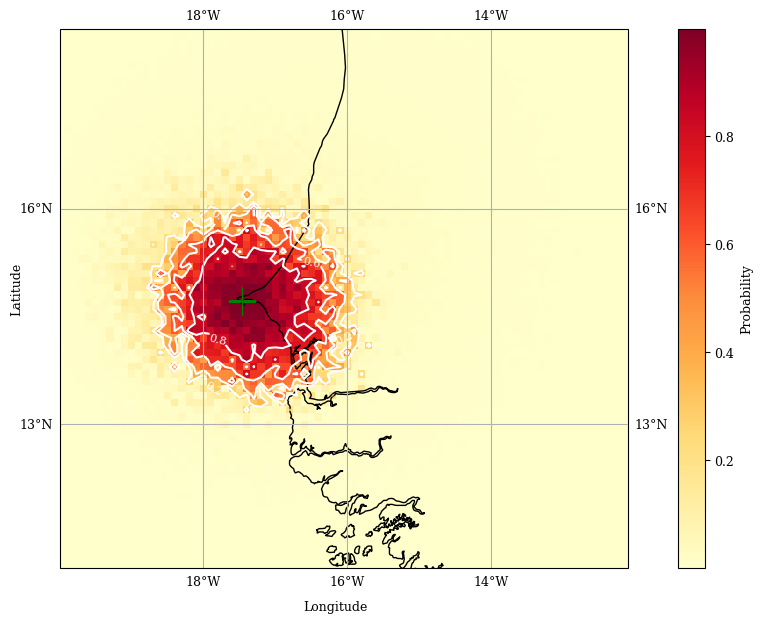

In [23]:
fig = plt.figure(figsize=(13, 7))

longitude = np.arange(-20, -12, 0.1)
latitude = np.arange(11, 19, 0.1)

lons, lats = np.meshgrid(longitude, latitude)
prob = y_pred.flatten().reshape(lons.shape).round(4)

ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-20, -12.1, 11, 18.5], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, edgecolor='gray')
#ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.COASTLINE)
ax.gridlines(xlocs=np.array([-18, -16, -14]), ylocs=np.array([10, 13, 16]), draw_labels=True, crs=ccrs.PlateCarree())

prob = gaussian_filter(prob, sigma=0)

plt.pcolormesh(lons, lats, prob, cmap="YlOrRd")
plt.colorbar(label='Probability')
contour = plt.contour(lons, lats, prob, colors='white', levels=5)
plt.plot(-17.4677, 14.7167, marker="+", color="green", markersize=20)
plt.clabel(contour, inline=True, fontsize=8)

fig.text(0.52, 0.05, "Longitude", ha='center')
fig.text(0.27, 0.51, "Latitude", va='center', rotation='vertical')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
#plt.title('Probability of storm in Dakar at t0+1h given a storms location at t0')
plt.show()
plt.show()

#### SHAP

In [162]:
def f(x):
    return model.predict(x).flatten()

In [163]:
test_data = test_data[field[:-1]]
test_data = test_data[test_data["lat5"] < 30] 
test_data = test_data[test_data["lon5"] < 30]

In [164]:
variable = "lon"
for i in range(5):
    print(np.min(test_data[f"{variable}{i+1}"]), np.max(test_data[f"{variable}{i+1}"]))

-17.97 -9.97
-17.92 -11.95
-17.97 -12.8
-17.97 -13.48
-17.97 -12.0


In [165]:
#test_data = raw_artificial_storm_data
original_test_data = prepare_for_test(test_data).to_numpy()

In [166]:
X = scaler.transform(original_test_data)
index = f(X)>0
X = X[index]
#y = y_true[index]
X_display = test_data[index]

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [167]:
X.shape

(115, 30)

In [168]:
explainer = shap.DeepExplainer(model, X)

/home/mendrika/anaconda3/lib/python3.10/site-packages/shap/explainers/_deep/deep_tf.py:99: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn("Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.")


In [169]:
n_shap = 1000

In [170]:
shap_values = explainer.shap_values(X[:n_shap])

In [171]:
if isinstance(shap_values, list):
    shap_values = shap_values[0]

In [172]:
shap_values = shap_values[:, :, 0]

In [173]:
list_of_features = ["ds", "size", "wp", "lat", "lon"]
feature_colors = ["red", "green", "blue", "black", "purple"]

In [174]:
parent_path = f"/home/mendrika/mendrika-phd/codes/nflics/output/SM2024-09-05/{location}"
global_path = f"{parent_path}/global-plots-t{lead_time}"
dep_path = f"{parent_path}/dependence-plots-t{lead_time}"

In [175]:
for directory in [parent_path, global_path, dep_path]:
    if not os.path.exists(directory):
        os.mkdir(directory)

In [176]:
plt.figure()
exp = shap.Explanation(shap_values[6], 
                       explainer.expected_value[0].numpy(),
                       feature_names=X_display.columns,
                       data=X_display.iloc[6,:]
                       )

shap.waterfall_plot(exp, max_display=11, show=False)
fig = plt.gcf()
fig.tight_layout()
fig.savefig(f"{global_path}/{location}-waterfall-lt{lead_time}.png")

In [177]:
shap.plots.force(exp)

In [178]:
shap_values.shape

(115, 30)

In [179]:
exp_many = shap.Explanation(shap_values, 
                                 explainer.expected_value[0].numpy(),
                                 data=X[:n_shap],
                                 feature_names=X_display.columns
                                 )

#shap.force_plot(exp_many, features=X_display.iloc[:],)

#### Absolute mean SHAP plot

In [180]:
plt.figure()
bars = shap.plots.bar(exp_many, max_display=11, show=False)
fig = plt.gcf()
ax = plt.gca()
for bar in ax.patches:
    bar.set_color("dimgray")
    bar.set_edgecolor("black")
for text in ax.texts:  # ax.texts contains all the text elements in the plot
    text.set_color('green')  # Change text color to green
    text.set_fontsize(12)
fig.tight_layout()
fig.savefig(f"{global_path}/{location}-bar-lt{lead_time}.png")

#### Violin plot

In [181]:
plt.figure()
shap.plots.violin(exp_many, plot_type="layered_violin", max_display=10, show=False)
fig = plt.gcf()
fig.tight_layout()
fig.savefig(f"{global_path}/{location}-violin-t{lead_time}.png")

#### Dependence plots

In [182]:
exp_many.shape

(115, 30)

### Plotting the dependence plots for multiple features

In [183]:
for feature_name, color in zip(list_of_features, feature_colors):
    for i in range(5):        
        plt.figure()
        shap.plots.scatter(exp_many[:, f"{feature_name}{i+1}"], show=False)    
        fig = plt.gcf()

        for ax in fig.get_axes():                   # Iterate through all axes in the figure
            for collection in ax.collections:       # collections holds scatter plots and other collections of points
                collection.set_color(color)
        fig.tight_layout()  

        dep_feature_path = f"{dep_path}/{feature_name}"
        if not os.path.exists(dep_feature_path):
            os.mkdir(dep_feature_path)
        fig.savefig(f"{dep_feature_path}/Dakar-{feature_name}{i+1}-lt{lead_time}.png")
        fig.show(False)

/home/mendrika/anaconda3/lib/python3.10/site-packages/shap/plots/_scatter.py:221: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = pl.figure(figsize=figsize)


#### Heatmap

In [184]:
plt.figure()
shap.plots.heatmap(exp_many, max_display=11, instance_order=exp_many.sum(1), show=False)
fig = plt.gcf()
fig.tight_layout()
fig.savefig(f"{global_path}/{location}-heatmap-lt{lead_time}.png")

In [185]:
plt.figure()
shap.plots.heatmap(exp_many, max_display=11, feature_values=exp_many.abs.max(0), show=False)
fig = plt.gcf()
fig.tight_layout()
fig.savefig(f"{global_path}/{location}-heatmap(1)-lt{lead_time}.png")